In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
!wget http://images.cocodataset.org/zips/val2014.zip
!unzip val2014.zip
!mkdir -p data/images
!mv val2014 data/images

!wget http://images.cocodataset.org/annotations/annotations_trainval2014.zip
!unzip annotations_trainval2014.zip
!mv annotations data/


!pip install pycocoevalcap



!pip install mteb

!pip install transformers torch sentence-transformers Pillow requests

In [1]:
!pip install open_clip_torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 34.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 56.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 59.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 49.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 22.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# **I. Code chạy đánh giá mô hình**

In [3]:
import torch
import json
import os
from transformers import pipeline
from PIL import Image
from pycocotools.coco import COCO
from tqdm import tqdm # For a nice progress bar

# --- SETUP ---
# Models to evaluate
models = [
    "Salesforce/blip-image-captioning-large",
    "Salesforce/blip-image-captioning-base",
    "nlpconnect/vit-gpt2-image-captioning",
    "ydshieh/vit-gpt2-coco-en",
    "microsoft/git-large",
    "microsoft/git-base",
    "Salesforce/blip2-opt-2.7b",
    "noamrot/FuseCap_Image_Captioning" 
]

# Paths and constants
dataDir = './data'
dataType = 'val2014'
annFile = f'{dataDir}/annotations/captions_{dataType}.json'
imgDir = f'{dataDir}/images/{dataType}'
NUM_IMAGES = 50

# Create a directory for results if it doesn't exist
os.makedirs('results', exist_ok=True)

# Detect GPU
device = 0 if torch.cuda.is_available() else -1
use_cuda = torch.cuda.is_available()

# --- LOAD DATASET (Done Once) ---
print("🥥 Loading COCO dataset...")
coco = COCO(annFile)
# Get the first 50 image IDs
imgIds = coco.getImgIds()[:NUM_IMAGES]
print(f"Loaded {len(imgIds)} images for evaluation.")


# --- MAIN LOOP FOR ALL MODELS ---
for model_name in models:
    print("=" * 80)
    print(f"🧠 Processing model: {model_name}")

    # Clear CUDA memory before loading the next model
    if use_cuda:
        torch.cuda.empty_cache()

    try:
        # Load the specific model's pipeline
        pipe = pipeline("image-to-text", model=model_name, device=device, max_new_tokens=20)

        results = []
        # Generate captions for the 50 images
        for imgId in tqdm(imgIds, desc=f"Model: {model_name.split('/')[-1]}"):
            img_info = coco.loadImgs(imgId)[0]
            img_path = os.path.join(imgDir, img_info['file_name'])
            image = Image.open(img_path).convert("RGB")
            
            # Generate caption
            generated_caption = pipe(image)[0]['generated_text']
            
            # Store result in the required format
            results.append({"image_id": imgId, "caption": generated_caption})

        # Define the output file for THIS model's results
        model_short_name = model_name.split("/")[-1]
        resFile = f'results/captions_{dataType}_{model_short_name}_results.json'

        # Save results to a unique JSON file
        print(f"\n✅ Saving results for {model_name} to {resFile}")
        with open(resFile, 'w') as f:
            json.dump(results, f)

    except Exception as e:
        print(f"\n❌ Failed to process model {model_name}. Error: {e}")

print("=" * 80)
print("All models processed.")

🥥 Loading COCO dataset...
loading annotations into memory...
Done (t=0.55s)
creating index...
index created!
Loaded 50 images for evaluation.
🧠 Processing model: Salesforce/blip-image-captioning-large


Device set to use cuda:0
Model: blip-image-captioning-large: 100%|██████████| 50/50 [00:15<00:00,  3.25it/s]



✅ Saving results for Salesforce/blip-image-captioning-large to results/captions_val2014_blip-image-captioning-large_results.json
🧠 Processing model: Salesforce/blip-image-captioning-base


Device set to use cuda:0
Model: blip-image-captioning-base: 100%|██████████| 50/50 [00:08<00:00,  5.58it/s]



✅ Saving results for Salesforce/blip-image-captioning-base to results/captions_val2014_blip-image-captioning-base_results.json
🧠 Processing model: nlpconnect/vit-gpt2-image-captioning


...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

Device set to use cuda:0

Model: FuseCap_Image_Captioning: 100%|██████████| 50/50 [00:22<00:00,  2.19it/s]


✅ Saving results for noamrot/FuseCap_Image_Captioning to results/captions_val2014_FuseCap_Image_Captioning_results.json
All models processed.


In [1]:
import torch
import time
from PIL import Image
import os
from transformers import (
    AutoProcessor, AutoTokenizer, AutoModelForCausalLM,
    BlipProcessor, BlipForConditionalGeneration,
    Blip2Processor, Blip2ForConditionalGeneration,
    VisionEncoderDecoderModel, AutoFeatureExtractor
)
from sentence_transformers import SentenceTransformer

# ==============================================================================
# 1. SETUP & CONFIGURATION
# ==============================================================================
IMAGE_FOLDER = "/kaggle/input/keyframes-l06/keyframes/L06_V001" # 🔁 Replace with your path
BATCH_SIZE = 8
MODELS_TO_EVALUATE = [
    "Salesforce/blip-image-captioning-large",
    "Salesforce/blip-image-captioning-base",
    "microsoft/git-large",
    "microsoft/git-base",
    "nlpconnect/vit-gpt2-image-captioning",
    "ydshieh/vit-gpt2-coco-en",
    "Salesforce/blip2-opt-2.7b"
]

# Set device
if not torch.cuda.is_available():
    print("⚠️ WARNING: CUDA is not available, using CPU. This will be very slow.")
    DEVICE = torch.device("cpu")
else:
    DEVICE = torch.device("cuda")
    print(f"✅ Found GPU: {torch.cuda.get_device_name(0)}")

# Load all image file paths
try:
    all_image_files = sorted([
        f for f in os.listdir(IMAGE_FOLDER)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    if not all_image_files:
        raise FileNotFoundError(f"No images found in folder: {IMAGE_FOLDER}")
    print(f"🖼️  Found {len(all_image_files)} images to process in batches of {BATCH_SIZE}.")
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    exit()

# --- Load the Sentence Embedding Model ---
print("\n🧠 Loading sentence embedding model...")
embedder = SentenceTransformer('all-MiniLM-L6-v2', device=DEVICE)
print("✅ Embedder loaded successfully.")

# --- Dictionary to store all results ---
master_results = {}

# ==============================================================================
# 2. MODEL EVALUATION LOOP
# ==============================================================================
for model_name in MODELS_TO_EVALUATE:
    print("\n" + "="*80)
    print(f"🧠 Evaluating model: {model_name}")
    print("="*80)

    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

    try:
        print("Loading captioning model and processor...")
        model_kwargs = {'torch_dtype': torch.float16} if DEVICE.type == 'cuda' else {}
        processor, model, feature_extractor, tokenizer = None, None, None, None

        if "blip2" in model_name:
            processor = Blip2Processor.from_pretrained(model_name)
            model = Blip2ForConditionalGeneration.from_pretrained(model_name, device_map="auto", **model_kwargs)
        elif "blip" in model_name:
            processor = BlipProcessor.from_pretrained(model_name)
            model = BlipForConditionalGeneration.from_pretrained(model_name, **model_kwargs).to(DEVICE)
        elif "git" in model_name:
            processor = AutoProcessor.from_pretrained(model_name)
            model = AutoModelForCausalLM.from_pretrained(model_name, **model_kwargs).to(DEVICE)
        elif "vit-gpt2" in model_name or "fusecap" in model_name:
            feature_extractor = AutoFeatureExtractor.from_pretrained(model_name)
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            model = VisionEncoderDecoderModel.from_pretrained(model_name, **model_kwargs).to(DEVICE)
        else:
            print(f"Unsupported model architecture for: {model_name}")
            continue

        model.eval()
        print("✅ Captioning model loaded successfully.")

        current_captions = []
        current_embeddings = []
        total_time = 0.0
        print(f"🚀 Starting inference...")

        for i in range(0, len(all_image_files), BATCH_SIZE):
            start_batch_time = time.time()
            batch_files = all_image_files[i : i + BATCH_SIZE]
            batch_images = [Image.open(os.path.join(IMAGE_FOLDER, f)).convert("RGB") for f in batch_files]

            print(f"  - Processing batch {i//BATCH_SIZE + 1}...", end="")

            with torch.no_grad():
                if processor:
                    inputs = processor(images=batch_images, return_tensors="pt", padding=True)
                else:
                    inputs = feature_extractor(images=batch_images, return_tensors="pt")

                inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
                output_ids = model.generate(**inputs, num_beams=1, max_new_tokens=30)

                if processor:
                    captions = processor.batch_decode(output_ids, skip_special_tokens=True)
                else:
                    captions = tokenizer.batch_decode(output_ids, skip_special_tokens=True)

                embeddings = embedder.encode(captions)
                current_captions.extend(captions)
                current_embeddings.extend(embeddings)

            batch_duration = time.time() - start_batch_time
            total_time += batch_duration
            print(f" Done in {batch_duration:.2f}s")

        master_results[model_name] = {
            "captions": current_captions,
            "embeddings": current_embeddings,
            "total_time": total_time # Store time for later analysis
        }

        print("\n--- Results for this model ---")
        print(f"⏱️  Total time taken: {total_time:.2f} seconds")
        if total_time > 0:
            throughput = len(all_image_files) / total_time
            # --- ADDED LATENCY CALCULATION ---
            average_latency = total_time / len(all_image_files)
            print(f"📊 Average Latency: {average_latency*1000:.2f} ms/image") # In milliseconds
            print(f"⚡ Average Throughput: {throughput:.2f} images/sec")
        print(f"📝 Example caption: '{current_captions[0]}'")

    except Exception as e:
        print(f"\n❌ An error occurred while evaluating {model_name}: {e}")
        continue

# ==============================================================================
# 3. FINAL SUMMARY
# ==============================================================================
print("\n" + "="*80)
print("✅ All models evaluated. Final data retained.")
print("="*80)

for model_name, data in master_results.items():
    print(f"📊 Summary for: {model_name}")
    print(f"  - Total captions stored: {len(data['captions'])}")
    if data['embeddings']:
        print(f"  - Shape of one embedding: {data['embeddings'][0].shape}")
    print("-" * 20)

2025-07-22 23:49:21.917510: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753228162.139222      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753228162.202181      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✅ Found GPU: Tesla P100-PCIE-16GB
🖼️  Found 284 images to process in batches of 8.

🧠 Loading sentence embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

 Done in 2.45s
  - Processing batch 35...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

 Done in 2.08s
  - Processing batch 36...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

 Done in 1.48s

--- Results for this model ---
⏱️  Total time taken: 77.06 seconds
📊 Average Latency: 271.35 ms/image
⚡ Average Throughput: 3.69 images/sec
📝 Example caption: 'a picture of a city with a lot of people in it
'

✅ All models evaluated. Final data retained.
📊 Summary for: Salesforce/blip-image-captioning-large
  - Total captions stored: 284
  - Shape of one embedding: (384,)
--------------------
📊 Summary for: Salesforce/blip-image-captioning-base
  - Total captions stored: 284
  - Shape of one embedding: (384,)
--------------------
📊 Summary for: microsoft/git-large
  - Total captions stored: 284
  - Shape of one embedding: (384,)
--------------------
📊 Summary for: microsoft/git-base
  - Total captions stored: 284
  - Shape of one embedding: (384,)
--------------------
📊 Summary for: nlpconnect/vit-gpt2-image-captioning
  - Total captions stored: 284
  - Shape of one embedding: (384,)
--------------------
📊 Summary for: ydshieh/vit-gpt2-coco-en
  - Total captions stored:

In [7]:
import os
import glob
from pycocotools.coco import COCO
from pycocoevalcap.eval import COCOEvalCap
import json

# --- SETUP ---

# Path to the ground-truth annotations
annFile = './data/annotations/captions_val2014.json'
# Directory where your result files are stored
resultsDir = 'results/'

# Find all model result files in the directory
# This pattern looks for files like: captions_val2014_..._results.json
search_pattern = os.path.join(resultsDir, 'captions_val2014_*_results.json')
result_files = glob.glob(search_pattern)

if not result_files:
    print(f"❌ No result files found in '{resultsDir}' matching the pattern.")
    print("Please make sure you have run the generation script first.")
else:
    print(f"Found {len(result_files)} result files to evaluate.")

# --- BATCH EVALUATION ---

# Load ground-truth annotations once
coco = COCO(annFile)

# Loop through each result file and evaluate it
for resFile in result_files:
    print("=" * 80)
    model_name = os.path.basename(resFile).replace('captions_val2014_', '').replace('_results.json', '')
    print(f"📊 Evaluating: {model_name}")
    print(f"   (File: {resFile})")

    try:
        # Create a cocoRes object with the specific results file
        cocoRes = coco.loadRes(resFile)

        # Create a new evaluation object for each model
        cocoEval = COCOEvalCap(coco, cocoRes)

        # IMPORTANT: Restrict evaluation to the images in the results file
        # This ensures you're only evaluating the 50 images you processed
        cocoEval.params['image_id'] = cocoRes.getImgIds()

        # Run the evaluation
        cocoEval.evaluate()

        # Print the scores for the current model
        for metric, score in cocoEval.eval.items():
            print(f'  {metric:<8}: {score:.4f}')

    except Exception as e:
        print(f"❌ Error evaluating file {resFile}: {e}")

print("=" * 80)
print("✅ All evaluations complete.")


Found 8 result files to evaluate.
loading annotations into memory...
Done (t=0.30s)
creating index...
index created!
📊 Evaluating: blip-image-captioning-base
   (File: results/captions_val2014_blip-image-captioning-base_results.json)
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
tokenization...


PTBTokenizer tokenized 3110 tokens at 31059.59 tokens per second.
PTBTokenizer tokenized 423 tokens at 5114.35 tokens per second.


setting up scorers...
computing Bleu score...
{'testlen': 367, 'reflen': 446, 'guess': [367, 317, 267, 217], 'correct': [308, 177, 78, 28]}
ratio: 0.8228699551551056
Bleu_1: 0.677
Bleu_2: 0.552
Bleu_3: 0.416
Bleu_4: 0.294
computing METEOR score...
METEOR: 0.249
computing Rouge score...
ROUGE_L: 0.556
computing CIDEr score...
CIDEr: 0.927
computing SPICE score...


Parsing reference captions
Parsing test captions
Initiating Stanford parsing pipeline
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator tokenize
[main] INFO edu.stanford.nlp.pipeline.TokenizerAnnotator - TokenizerAnnotator: No tokenizer type provided. Defaulting to PTBTokenizer.
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator ssplit
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator parse
[main] INFO edu.stanford.nlp.parser.common.ParserGrammar - Loading parser from serialized file edu/stanford/nlp/models/lexparser/englishPCFG.ser.gz ... 
done [0.7 sec].
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator lemma
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator ner
Loading classifier from edu/stanford/nlp/models/ner/english.all.3class.distsim.crf.ser.gz ... done [1.3 sec].
Loading classifier from edu/stanford/nlp/models/ner/english.muc.7class.distsim.crf.ser.gz ... done [0.7

SPICE evaluation took: 8.453 s
SPICE: 0.159
  Bleu_1  : 0.6767
  Bleu_2  : 0.5520
  Bleu_3  : 0.4156
  Bleu_4  : 0.2940
  METEOR  : 0.2489
  ROUGE_L : 0.5557
  CIDEr   : 0.9267
  SPICE   : 0.1593
📊 Evaluating: git-large
   (File: results/captions_val2014_git-large_results.json)
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
tokenization...


...

SPICE evaluation took: 8.348 s
SPICE: 0.112
  Bleu_1  : 0.3570
  Bleu_2  : 0.2421
  Bleu_3  : 0.1616
  Bleu_4  : 0.1193
  METEOR  : 0.1638
  ROUGE_L : 0.3861
  CIDEr   : 0.4632
  SPICE   : 0.1124
📊 Evaluating: vit-gpt2-image-captioning
   (File: results/captions_val2014_vit-gpt2-image-captioning_results.json)
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
tokenization...


PTBTokenizer tokenized 3110 tokens at 30594.58 tokens per second.
PTBTokenizer tokenized 555 tokens at 6587.75 tokens per second.


setting up scorers...
computing Bleu score...
{'testlen': 480, 'reflen': 486, 'guess': [480, 430, 380, 330], 'correct': [362, 205, 101, 42]}
ratio: 0.9876543209856221
Bleu_1: 0.745
Bleu_2: 0.592
Bleu_3: 0.452
Bleu_4: 0.328
computing METEOR score...
METEOR: 0.272
computing Rouge score...
ROUGE_L: 0.565
computing CIDEr score...
CIDEr: 1.101
computing SPICE score...


Parsing reference captions
Parsing test captions


SPICE evaluation took: 1.330 s
SPICE: 0.182
  Bleu_1  : 0.7448
  Bleu_2  : 0.5922
  Bleu_3  : 0.4515
  Bleu_4  : 0.3280
  METEOR  : 0.2721
  ROUGE_L : 0.5655
  CIDEr   : 1.1006
  SPICE   : 0.1824
✅ All evaluations complete.


In [4]:
import torch
import time
from PIL import Image
import os
from transformers import (
    AutoProcessor, AutoTokenizer, AutoModelForCausalLM,
    BlipProcessor, BlipForConditionalGeneration,
    Blip2Processor, Blip2ForConditionalGeneration,
    VisionEncoderDecoderModel, AutoFeatureExtractor
)
from sentence_transformers import SentenceTransformer

# ==============================================================================
# 1. SETUP & CONFIGURATION
# ==============================================================================
IMAGE_FOLDER = "/kaggle/input/keyframes-l06/keyframes/L06_V001" # 🔁 Replace with your path
BATCH_SIZE = 8
MODELS_TO_EVALUATE = [

    "Salesforce/blip-image-captioning-large",
    "Salesforce/blip-image-captioning-base",
    "nlpconnect/vit-gpt2-image-captioning",
    "ydshieh/vit-gpt2-coco-en",
    "microsoft/git-large",
    "microsoft/git-base",
    "noamrot/FuseCap_Image_Captioning",
    "Salesforce/blip2-opt-2.7b"

]

# Set device
if not torch.cuda.is_available():
    print("⚠️ WARNING: CUDA is not available, using CPU. This will be very slow.")
    DEVICE = torch.device("cpu")
else:
    DEVICE = torch.device("cuda")
    print(f"✅ Found GPU: {torch.cuda.get_device_name(0)}")

# Load all image file paths
try:
    all_image_files = sorted([
        f for f in os.listdir(IMAGE_FOLDER)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    if not all_image_files:
        raise FileNotFoundError(f"No images found in folder: {IMAGE_FOLDER}")
    print(f"🖼️  Found {len(all_image_files)} images to process in batches of {BATCH_SIZE}.")
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    exit()

# --- Load the Sentence Embedding Model ---
print("\n🧠 Loading sentence embedding model...")
embedder = SentenceTransformer('all-MiniLM-L6-v2', device=DEVICE)
print("✅ Embedder loaded successfully.")

# --- Dictionary to store all results ---
master_results = {}

# ==============================================================================
# 2. MODEL EVALUATION LOOP
# ==============================================================================
for model_name in MODELS_TO_EVALUATE:
    print("\n" + "="*80)
    print(f"🧠 Evaluating model: {model_name}")
    print("="*80)

    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

    try:
        print("Loading captioning model and processor...")
        model_kwargs = {'torch_dtype': torch.float16} if DEVICE.type == 'cuda' else {}
        processor, model, feature_extractor, tokenizer = None, None, None, None

        if "blip2" in model_name:
            processor = Blip2Processor.from_pretrained(model_name)
            model = Blip2ForConditionalGeneration.from_pretrained(model_name, device_map="auto", **model_kwargs)
        elif "blip" in model_name:
            processor = BlipProcessor.from_pretrained(model_name)
            model = BlipForConditionalGeneration.from_pretrained(model_name, **model_kwargs).to(DEVICE)
        elif "git" in model_name:
            processor = AutoProcessor.from_pretrained(model_name)
            model = AutoModelForCausalLM.from_pretrained(model_name, **model_kwargs).to(DEVICE)
        elif "vit-gpt2" in model_name or "fusecap" in model_name:
            feature_extractor = AutoFeatureExtractor.from_pretrained(model_name)
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            model = VisionEncoderDecoderModel.from_pretrained(model_name, **model_kwargs).to(DEVICE)
        else:
            print(f"Unsupported model architecture for: {model_name}")
            continue

        model.eval()
        print("✅ Captioning model loaded successfully.")

        # --- Prepare lists for the current model's results ---
        current_captions = []
        current_embeddings = []
        total_time = 0.0
        print(f"🚀 Starting inference...")

        for i in range(0, len(all_image_files), BATCH_SIZE):
            start_batch_time = time.time()
            batch_files = all_image_files[i : i + BATCH_SIZE]
            batch_images = [Image.open(os.path.join(IMAGE_FOLDER, f)).convert("RGB") for f in batch_files]

            print(f"  - Processing batch {i//BATCH_SIZE + 1}...", end="")

            with torch.no_grad():
                if processor:
                    inputs = processor(images=batch_images, return_tensors="pt", padding=True)
                else:
                    inputs = feature_extractor(images=batch_images, return_tensors="pt")

                inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
                output_ids = model.generate(**inputs, num_beams=1, max_new_tokens=30)

                if processor:
                    captions = processor.batch_decode(output_ids, skip_special_tokens=True)
                else:
                    captions = tokenizer.batch_decode(output_ids, skip_special_tokens=True)

                embeddings = embedder.encode(captions)
                current_captions.extend(captions)
                current_embeddings.extend(embeddings)

            batch_duration = time.time() - start_batch_time
            total_time += batch_duration
            print(f" Done in {batch_duration:.2f}s")

        # --- Store the results for the current model in the master dictionary ---
        master_results[model_name] = {
            "embeddings": current_embeddings
        }

        print("\n--- Results for this model ---")
        print(f"⏱️  Total time taken: {total_time:.2f} seconds")
        if total_time > 0:
            throughput = len(all_image_files) / total_time
            print(f"⚡ Average throughput: {throughput:.2f} images/sec")
        print(f"📝 Example caption: '{current_captions[0]}'")

    except Exception as e:
        print(f"\n❌ An error occurred while evaluating {model_name}: {e}")
        continue



✅ Found GPU: Tesla P100-PCIE-16GB
🖼️  Found 284 images to process in batches of 8.

🧠 Loading sentence embedding model...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


✅ Embedder loaded successfully.

🧠 Evaluating model: Salesforce/blip-image-captioning-large
Loading captioning model and processor...


preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/527 [00:00<?, ?B/s]

...

 Done in 2.47s
  - Processing batch 35...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

 Done in 2.06s
  - Processing batch 36...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

 Done in 1.50s

--- Results for this model ---
⏱️  Total time taken: 77.32 seconds
⚡ Average throughput: 3.67 images/sec
📝 Example caption: 'a picture of a city with a lot of people in it
'


In [4]:
import torch
from sentence_transformers import SentenceTransformer
import time
import numpy as np

# --- Configuration ---
models_to_test = [
    'all-MiniLM-L6-v2',
    'all-mpnet-base-v2',
    'paraphrase-multilingual-mpnet-base-v2',
    'BAAI/bge-large-en-v1.5'
]

# Benchmark parameters
batch_size = 32
num_sentences = 1024
warmup_batches = 5
test_batches = 20

# Create dummy sentences for testing
# Using a representative sentence length is important for realistic results.
dummy_sentence = "This is a representative sentence for benchmarking sentence embedding models."
sentences = [dummy_sentence] * num_sentences

# Determine device (GPU if available, otherwise CPU)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"--- Running benchmark on {device.upper()} ---")
print(f"Batch Size: {batch_size}, Total Sentences per run: {test_batches * batch_size}\n")


# --- Main Loop ---
for model_name in models_to_test:
    print(f"--- Benchmarking Model: {model_name} ---")

    try:
        # 1. Load Model and move to device
        # Reset VRAM stats for accurate measurement of model loading
        if device == 'cuda':
            torch.cuda.reset_peak_memory_stats()
        
        model = SentenceTransformer(model_name, device=device)
        
        if device == 'cuda':
            # VRAM used by just loading the model
            vram_after_load_mb = torch.cuda.max_memory_allocated() / (1024**2)
            print(f"VRAM after model load: {vram_after_load_mb:.2f} MB")
        
        # 2. Warm-up Phase (to avoid counting initial setup costs)
        print("Running warm-up...")
        for _ in range(warmup_batches):
            model.encode(sentences[:batch_size], batch_size=batch_size, show_progress_bar=False)

        # 3. Benchmark Phase
        print("Running benchmark...")
        if device == 'cuda':
             # Reset stats again to measure only the inference workload
            torch.cuda.reset_peak_memory_stats()

        start_time = time.perf_counter()

        for i in range(0, test_batches * batch_size, batch_size):
            batch = sentences[i : i + batch_size]
            model.encode(batch, batch_size=batch_size, show_progress_bar=False)

        end_time = time.perf_counter()

        # 4. Calculate and Print Metrics
        total_time = end_time - start_time
        total_sentences_processed = test_batches * batch_size
        
        latency_per_batch = (total_time / test_batches) * 1000  # in milliseconds
        throughput = total_sentences_processed / total_time
        
        peak_vram_mb = 0
        if device == 'cuda':
            peak_vram_mb = torch.cuda.max_memory_allocated() / (1024**2)

        print("\n--- Results ---")
        print(f"Avg. Latency per Batch: {latency_per_batch:.2f} ms")
        print(f"Throughput: {throughput:.2f} sentences/sec")
        if device == 'cuda':
            print(f"Peak VRAM during inference: {peak_vram_mb:.2f} MB")
        print("-" * 30 + "\n")

    except Exception as e:
        print(f"Failed to benchmark {model_name}. Error: {e}\n")
    
    finally:
        # Clean up memory before next model
        del model
        if device == 'cuda':
            torch.cuda.empty_cache()

--- Running benchmark on CUDA ---
Batch Size: 32, Total Sentences per run: 640

--- Benchmarking Model: all-MiniLM-L6-v2 ---
VRAM after model load: 8491.49 MB
Running warm-up...
Running benchmark...

--- Results ---
Avg. Latency per Batch: 8.16 ms
Throughput: 3919.78 sentences/sec
Peak VRAM during inference: 1148.82 MB
------------------------------

--- Benchmarking Model: all-mpnet-base-v2 ---


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

VRAM after model load: 3816.06 MB
Running warm-up...
Running benchmark...

--- Results ---
Avg. Latency per Batch: 74.84 ms
Throughput: 427.59 sentences/sec
Peak VRAM during inference: 3839.45 MB
------------------------------



In [3]:
import torch
import time
import requests
from PIL import Image
from transformers import pipeline, AutoModel, AutoTokenizer
from sentence_transformers import SentenceTransformer

# Check if a GPU is available and set the device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# --- Helper Function for Benchmarking ---
def benchmark_model(model_name, task, batch_size=32):
    """
    Measures Latency, Peak VRAM, and Throughput for a given model.
    """
    if device == "cpu":
        print("VRAM measurement is only available on CUDA devices.")
        return

    # 1. LATENCY (single item inference time)
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(device)

    if task == "image-to-text":
        # Prepare for image captioning
        pipe = pipeline(task, model=model_name, device=device)
        image_path = "/kaggle/input/keyframes-l06/keyframes/L06_V001/001.jpg"
        image = Image.open(image_path).convert("RGB")
        
        # Warm-up run
        _ = pipe(image)

        start_time = time.perf_counter()
        _ = pipe(image, max_new_tokens=20) # Generate caption for one image
        end_time = time.perf_counter()
        latency = (end_time - start_time) * 1000 # in milliseconds
        
    elif task == "sentence-embedding":
        # Prepare for sentence embedding
        model = SentenceTransformer(model_name, device=device)
        sample_sentence = "This is a test sentence."
        
        # Warm-up run
        _ = model.encode(sample_sentence)
        
        start_time = time.perf_counter()
        _ = model.encode(sample_sentence)
        end_time = time.perf_counter()
        latency = (end_time - start_time) * 1000 # in milliseconds

    # 2. PEAK VRAM
    peak_vram = torch.cuda.max_memory_allocated(device) / (1024 ** 2) # in MB
    
    # 3. THROUGHPUT (items per second)
    torch.cuda.empty_cache()
    if task == "image-to-text":
        # Batch of identical images for throughput test
        images = [image] * batch_size
        start_time = time.perf_counter()
        _ = pipe(images, batch_size=batch_size, max_new_tokens=20)
        end_time = time.perf_counter()
    elif task == "sentence-embedding":
        # Batch of sentences for throughput test
        sentences = ["This is a test sentence."] * batch_size
        start_time = time.perf_counter()
        _ = model.encode(sentences, batch_size=batch_size)
        end_time = time.perf_counter()

    total_time = end_time - start_time
    throughput = batch_size / total_time if total_time > 0 else float('inf')

    # Print results
    print(f"--- Results for: {model_name} ---")
    print(f"Latency (1 item): {latency:.2f} ms")
    print(f"Peak VRAM Usage: {peak_vram:.2f} MB")
    print(f"Throughput ({batch_size} items): {throughput:.2f} items/sec")
    print("-" * 35 + "\n")


# --- RUNNING THE EVALUATION ---

# Part 1: Image Captioning Model
print("### Benchmarking Image Captioning Model ###\n")
benchmark_model("nlpconnect/vit-gpt2-image-captioning", "image-to-text", batch_size=8)

# Part 2: Sentence Embedding Models
print("### Benchmarking Sentence Embedding Models ###\n")
sentence_models = [
    "all-mpnet-base-v2",
    "all-MiniLM-L6-v2",
    "BAAI/bge-large-en-v1.5",
    "paraphrase-multilingual-mpnet-base-v2"
]
for model_name in sentence_models:
    benchmark_model(model_name, "sentence-embedding", batch_size=128)

Using device: cuda
### Benchmarking Image Captioning Model ###



Device set to use cuda
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.
Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.53.0. You should pass an instance of `Cache` instead, e.g. `past_key_values=DynamicCache.from_legacy_cache(past_key_values)`.


--- Results for: nlpconnect/vit-gpt2-image-captioning ---
Latency (1 item): 205.51 ms
Peak VRAM Usage: 2846.49 MB
Throughput (8 items): 25.20 items/sec
-----------------------------------

### Benchmarking Sentence Embedding Models ###



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

--- Results for: paraphrase-multilingual-mpnet-base-v2 ---
Latency (1 item): 22.17 ms
Peak VRAM Usage: 3667.84 MB
Throughput (128 items): 2406.78 items/sec
-----------------------------------



In [17]:
import torch
import time
from PIL import Image
import os
from transformers import (
    AutoProcessor, AutoTokenizer, AutoModelForCausalLM,
    BlipProcessor, BlipForConditionalGeneration,
    Blip2Processor, Blip2ForConditionalGeneration,
    VisionEncoderDecoderModel, AutoFeatureExtractor
)
from sentence_transformers import SentenceTransformer

# ==============================================================================
# 1. SETUP & CONFIGURATION
# ==============================================================================
IMAGE_FOLDER = "/kaggle/input/keyframes-l06/keyframes/L06_V001"  # Replace with your path
BATCH_SIZE = 8

MODELS_TO_EVALUATE = [
    "nlpconnect/vit-gpt2-image-captioning",
]

TEXT_EMBEDDING_MODELS = [
    "all-MiniLM-L6-v2",
    "all-mpnet-base-v2",
    "paraphrase-multilingual-mpnet-base-v2",
    "BAAI/bge-large-en-v1.5",
]

if not torch.cuda.is_available():
    print("⚠️ WARNING: CUDA is not available, using CPU.")
    DEVICE = torch.device("cpu")
else:
    DEVICE = torch.device("cuda")
    print(f"✅ Found GPU: {torch.cuda.get_device_name(0)}")

try:
    all_image_files = sorted([
        f for f in os.listdir(IMAGE_FOLDER)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    if not all_image_files:
        raise FileNotFoundError(f"No images found in folder: {IMAGE_FOLDER}")
    print(f"🖼️  Found {len(all_image_files)} images to process in batches of {BATCH_SIZE}.")
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    exit()

# Dictionary to store all results
master_results = {}

# ==============================================================================
# 2. MODEL EVALUATION LOOP
# ==============================================================================
for model_name in MODELS_TO_EVALUATE:
    print("\n" + "=" * 80)
    print(f"🧠 Evaluating model: {model_name}")
    print("=" * 80)

    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

    try:
        print("Loading captioning model and processor...")
        model_kwargs = {'torch_dtype': torch.float16} if DEVICE.type == 'cuda' else {}
        processor, model, feature_extractor, tokenizer = None, None, None, None

        if "blip2" in model_name:
            processor = Blip2Processor.from_pretrained(model_name)
            model = Blip2ForConditionalGeneration.from_pretrained(model_name, device_map="auto", **model_kwargs)
        elif "blip" in model_name:
            processor = BlipProcessor.from_pretrained(model_name)
            model = BlipForConditionalGeneration.from_pretrained(model_name, **model_kwargs).to(DEVICE)
        elif "git" in model_name:
            processor = AutoProcessor.from_pretrained(model_name)
            model = AutoModelForCausalLM.from_pretrained(model_name, **model_kwargs).to(DEVICE)
        elif "vit-gpt2" in model_name or "fusecap" in model_name:
            feature_extractor = AutoFeatureExtractor.from_pretrained(model_name)
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            model = VisionEncoderDecoderModel.from_pretrained(model_name, **model_kwargs).to(DEVICE)
        else:
            print(f"Unsupported model architecture for: {model_name}")
            continue

        model.eval()
        print("✅ Captioning model loaded successfully.")

        current_captions = []
        total_time = 0.0
        print(f"🚀 Starting inference...")

        for i in range(0, len(all_image_files), BATCH_SIZE):
            start_batch_time = time.time()
            batch_files = all_image_files[i: i + BATCH_SIZE]
            batch_images = [Image.open(os.path.join(IMAGE_FOLDER, f)).convert("RGB") for f in batch_files]

            print(f"  - Processing batch {i // BATCH_SIZE + 1}...", end="")

            with torch.no_grad():
                if processor:
                    inputs = processor(images=batch_images, return_tensors="pt", padding=True)
                else:
                    inputs = feature_extractor(images=batch_images, return_tensors="pt")

                inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
                output_ids = model.generate(**inputs, num_beams=1, max_new_tokens=30)

                if processor:
                    captions = processor.batch_decode(output_ids, skip_special_tokens=True)
                else:
                    captions = tokenizer.batch_decode(output_ids, skip_special_tokens=True)

                current_captions.extend(captions)

            batch_duration = time.time() - start_batch_time
            total_time += batch_duration
            print(f" Done in {batch_duration:.2f}s")

        # Initialize nested result storage
        master_results[model_name] = {}

        # --- Encode Captions with Multiple Embedding Models ---
        print(f"\n💬 Generated {len(current_captions)} captions. Now encoding with text embedding models...")

        for emb_model_name in TEXT_EMBEDDING_MODELS:
            print(f"  🔍 Encoding using: {emb_model_name}")
            embedder = SentenceTransformer(emb_model_name, device=DEVICE)
            embeddings = embedder.encode(current_captions, convert_to_numpy=True, show_progress_bar=True)
            master_results[model_name][emb_model_name] = {
                "embeddings": embeddings,
                #"captions": current_captions  # Optional: only once since captions are same
            }

        print("\n--- Results for this model ---")
        print(f"⏱️  Total time taken: {total_time:.2f} seconds")
        if total_time > 0:
            throughput = len(all_image_files) / total_time
            print(f"⚡ Average throughput: {throughput:.2f} images/sec")
        print(f"📝 Example caption: '{current_captions[0]}'")

    except Exception as e:
        print(f"\n❌ An error occurred while evaluating {model_name}: {e}")
        continue


✅ Found GPU: Tesla T4
🖼️  Found 284 images to process in batches of 8.

🧠 Evaluating model: nlpconnect/vit-gpt2-image-captioning
Loading captioning model and processor...
✅ Captioning model loaded successfully.
🚀 Starting inference...
  - Processing batch 1... Done in 0.48s
  - Processing batch 2... Done in 0.43s
  - Processing batch 3... Done in 0.42s
  - Processing batch 4... Done in 0.35s
  - Processing batch 5... Done in 0.44s
  - Processing batch 6... Done in 0.37s
  - Processing batch 7... Done in 0.39s
  - Processing batch 8... Done in 0.38s
  - Processing batch 9... Done in 0.44s
  - Processing batch 10... Done in 0.42s
  - Processing batch 11... Done in 0.43s
  - Processing batch 12... Done in 0.35s
  - Processing batch 13... Done in 0.42s
  - Processing batch 14... Done in 0.39s
  - Processing batch 15... Done in 0.42s
  - Processing batch 16... Done in 0.41s
  - Processing batch 17... Done in 0.42s
  - Processing batch 18... Done in 0.39s
  - Processing batch 19... Done in 0

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

  🔍 Encoding using: all-mpnet-base-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]


--- Results for this model ---
⏱️  Total time taken: 14.22 seconds
⚡ Average throughput: 19.98 images/sec
📝 Example caption: 'a cityscape with a large bridge and a large clock '


In [16]:
import numpy as np
from scipy.stats import spearmanr
from datasets import load_dataset, concatenate_datasets
from sentence_transformers import SentenceTransformer, util

# Models to evaluate
TEXT_EMBEDDING_MODELS = [
    "all-MiniLM-L6-v2",
    "all-mpnet-base-v2",
    "paraphrase-multilingual-mpnet-base-v2",
    "BAAI/bge-large-en-v1.5",
]

# Load and concatenate train, validation, and test splits
dataset = load_dataset("mteb/stsbenchmark-sts")
full_dataset = concatenate_datasets([dataset["train"], dataset["validation"], dataset["test"]])

# Extract sentence pairs and similarity scores
sentences1 = full_dataset["sentence1"]
sentences2 = full_dataset["sentence2"]
gold_scores = np.array(full_dataset["score"]) / 5.0  # Normalize to [0, 1]

# Loop over each embedding model
for model_name in TEXT_EMBEDDING_MODELS:
    print(f"\n🔍 Evaluating model: {model_name}")
    
    # Load sentence transformer model
    model = SentenceTransformer(model_name)

    # Encode sentences into embeddings
    embeddings1 = model.encode(sentences1, convert_to_tensor=True, show_progress_bar=True)
    embeddings2 = model.encode(sentences2, convert_to_tensor=True, show_progress_bar=True)

    # Compute cosine similarities
    cosine_scores = util.cos_sim(embeddings1, embeddings2).diagonal().cpu().numpy()

    # Compute Spearman correlation
    spearman_corr, _ = spearmanr(cosine_scores, gold_scores)
    print(f"📈 Spearman Correlation: {spearman_corr:.4f}")



🔍 Evaluating model: all-MiniLM-L6-v2


Batches:   0%|          | 0/270 [00:00<?, ?it/s]

Batches:   0%|          | 0/270 [00:00<?, ?it/s]

📈 Spearman Correlation: 0.8240

🔍 Evaluating model: all-mpnet-base-v2


Batches:   0%|          | 0/270 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/270 [00:00<?, ?it/s]

📈 Spearman Correlation: 0.8685

🔍 Evaluating model: BAAI/bge-large-en-v1.5


Batches:   0%|          | 0/270 [00:00<?, ?it/s]

Batches:   0%|          | 0/270 [00:00<?, ?it/s]

📈 Spearman Correlation: 0.8793


# **II. Thông số sau khi chạy đánh giá mô hình**

### 🚀 Hiệu năng model image captioning trên 1 ảnh
| Mô hình                                    | Latency (s) | Peak VRAM | Throughput (img/s) |
| ------------------------------------------ | ----------- | --------- | ------------------ |
| **Salesforce/blip-image-captioning-large** | 1.388       | 1.83 GB   | 2.64               |
| **Salesforce/blip-image-captioning-base**  | 0.386       | 2.69 GB   | 3.12               |
| **nlpconnect/vit-gpt2-image-captioning**   | 0.337       | 1.85 GB   | 4.42               |
| **ydshieh/vit-gpt2-coco-en**               | 0.477       | 1.84 GB   | 2.24               |
| **microsoft/git-large**                    | 0.749       | 2.40 GB   | 1.18               |
| **microsoft/git-base**                     | 0.130       | 2.14 GB   | 8.19               |
| **noamrot/FuseCap\_Image\_Captioning**     | 0.900       | 1.59 GB   | 1.50               |
| **Salesforce/blip2-opt-2.7b**              | 0.624       | 15.09 GB  | 1.75               |


### 🚀 Độ chính xác của model image captioning trên 50 ảnh tập COCO
| Mô hình                         | BLEU-4 | METEOR | ROUGE\_L | CIDEr      | SPICE     |
| ------------------------------- | ------ | ------ | -------- | ---------- | --------- |
| **blip-image-captioning-large** | 0.2720 | 0.2823 | 0.5135   | 1.0399     | **0.206** |
| **blip-image-captioning-base**  | 0.2940 | 0.2489 | 0.5557   | 0.9267     | 0.1593    |
| **vit-gpt2-image-captioning**   | 0.3280 | 0.2721 | 0.5655   | **1.1006** | 0.1824    |
| **vit-gpt2-coco-en**            | 0.3280 | 0.2721 | 0.5655   | 1.1006     | 0.1824    |
| **git-large**                   | 0.0958 | 0.1608 | 0.3980   | 0.4771     | 0.1192    |
| **git-base**                    | 0.1193 | 0.1638 | 0.3861   | 0.4632     | 0.1124    |
| **FuseCap\_Image\_Captioning**  | 0.0957 | 0.2151 | 0.3680   | 0.2781     | 0.1450    |
| **blip2-opt-2.7b**              | 0.1169 | 0.1573 | 0.4075   | 0.3109     | 0.0815    |


### 🚀 Hiệu năng các model image captioning và model text embedding all-MiniLM-L6-v2 trên L06_V001

| Mô hình                             | Total Time (s) | Throughput (images/sec) |
|------------------------------------|----------------|--------------------------|
| **blip-image-captioning-large**    | 47.12          | 6.03                     |
| **blip-image-captioning-base**     | 28.77          | 9.87                     |
| **vit-gpt2-image-captioning**      | 14.92          | **19.04**                |
| **vit-gpt2-coco-en**               | 17.01          | 16.70                    |
| **git-large**                      | 217.87         | 1.30                     |
| **git-base**                       | 41.75          | 6.80                     |
| **blip2-opt-2.7b**                 | 77.32          | 3.67                     |


### 🚀 Hiệu năng của model text embedding trên 1024 sentences, Độ chính xác trên dataset mteb/stsbenchmark-sts

| Mô hình                                | VRAM Load (MB) | Peak VRAM (MB) | Latency/Batch (ms) | Throughput (sent/sec) | Spearman Correlation |
|----------------------------------------|----------------|----------------|---------------------|------------------------|-----------------------|
| **all-MiniLM-L6-v2**                   | 8491.49        | 1148.82        | **8.16**            | **3919.78**            | 0.8240                |
| **all-mpnet-base-v2**                  | 1475.03        | 1494.21        | 24.89               | 1285.86                | 0.8490                |
| **paraphrase-multilingual-mpnet-base-v2** | 2536.09     | 2554.85        | 27.42               | 1167.12                | 0.8685                |
| **BAAI/bge-large-en-v1.5**             | 3816.06        | 3839.45        | 74.84               | 427.59                 | **0.8793**            |



# **III. Thực nghiệm**

In [2]:
import torch
import time
import os
from PIL import Image
from transformers import VisionEncoderDecoderModel, AutoTokenizer, AutoFeatureExtractor
from sentence_transformers import SentenceTransformer

# ==============================================================================
# CONFIGURATION
# ==============================================================================
CAPTION_MODEL_NAME = "nlpconnect/vit-gpt2-image-captioning"
EMBED_MODEL_NAME = "all-MiniLM-L6-v2"
BATCH_SIZE = 8

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {DEVICE}")

# ==============================================================================
# LOAD MODELS (Once, globally)
# ==============================================================================
print("📦 Loading models...")
feature_extractor = AutoFeatureExtractor.from_pretrained(CAPTION_MODEL_NAME)
caption_tokenizer = AutoTokenizer.from_pretrained(CAPTION_MODEL_NAME)
caption_model = VisionEncoderDecoderModel.from_pretrained(CAPTION_MODEL_NAME).to(DEVICE)
caption_model.eval()

embedder = SentenceTransformer(EMBED_MODEL_NAME, device=DEVICE)
print("✅ Models loaded.")


def generate_caption_embeddings(
    image_folder: str,
    batch_size: int = BATCH_SIZE,
    feature_extractor=None,
    tokenizer=None,
    caption_model=None,
    embedder=None
):
    image_files = sorted([
        f for f in os.listdir(image_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])
    print(f"🖼️ Found {len(image_files)} images in {image_folder}")

    embeddings = []

    for i in range(0, len(image_files), batch_size):
        batch_files = image_files[i:i + batch_size]
        batch_images = [
            Image.open(os.path.join(image_folder, f)).convert("RGB")
            for f in batch_files
        ]

        inputs = feature_extractor(images=batch_images, return_tensors="pt").to(DEVICE)

        with torch.no_grad():
            output_ids = caption_model.generate(**inputs, num_beams=1, max_new_tokens=30)
            batch_captions = tokenizer.batch_decode(output_ids, skip_special_tokens=True)
            batch_embeddings = embedder.encode(batch_captions, convert_to_tensor=True).cpu().numpy()

        embeddings.extend(batch_embeddings)

    return embeddings



2025-07-25 06:02:05.562884: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753423325.733101      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753423325.785792      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✅ Using device: cuda
📦 Loading models...


preprocessor_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/models/vit/feature_extraction_vit.py:30: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/241 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Models loaded.


In [38]:
import open_clip
from PIL import Image
import torch
import os
from open_clip import tokenize
# ========================================================
# Load model and tokenizer
# ========================================================
CLIP_MODEL_NAME = 'hf-hub:apple/DFN5B-CLIP-ViT-H-14-378'
#'hf-hub:laion/CLIP-ViT-H-14-laion2B-s32B-b79K'
clip_model, _, preprocess = open_clip.create_model_and_transforms(CLIP_MODEL_NAME, pretrained=None)
clip_tokenizer = open_clip.get_tokenizer(CLIP_MODEL_NAME)
clip_model.eval().cuda()  # or use .to(device)


def generate_image_embeddings(
    image_folder: str,
    batch_size: int = 8,
    model=None,
    preprocess=None,
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
):
    image_files = sorted([
        f for f in os.listdir(image_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])
    print(f"🖼️ Found {len(image_files)} images in {image_folder}")

    all_embeddings = []

    for i in range(0, len(image_files), batch_size):
        batch_files = image_files[i:i+batch_size]
        batch_images = [
            preprocess(Image.open(os.path.join(image_folder, f)).convert("RGB"))
            for f in batch_files
        ]
        images_tensor = torch.stack(batch_images).to(device)

        with torch.no_grad():
            image_features = model.encode_image(images_tensor)
            image_features /= image_features.norm(dim=-1, keepdim=True)

        all_embeddings.extend(image_features.cpu().numpy())

    return all_embeddings



open_clip_config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/3.95G [00:00<?, ?B/s]

In [39]:
# Step 1: Get embeddings
image_folder = "/kaggle/input/keyframes-l06/keyframes/L06_V001"
image_files = sorted([
    f for f in os.listdir(image_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])
caption_embeds = generate_caption_embeddings(
    image_folder=image_folder,
    batch_size=8,
    feature_extractor=feature_extractor,
    tokenizer=caption_tokenizer,
    caption_model=caption_model,
    embedder=embedder
)
clip_embeds = generate_image_embeddings(
    image_folder=image_folder,
    batch_size=8,
    model=clip_model,
    preprocess=preprocess
)



🖼️ Found 284 images in /kaggle/input/keyframes-l06/keyframes/L06_V001


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

🖼️ Found 284 images in /kaggle/input/keyframes-l06/keyframes/L06_V001


In [31]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
import os

def search_similar_images(
    query: str,
    clip_embeddings: list,
    caption_embeddings: list,
    image_files: list,
    image_folder: str,
    modality: str = "fusion",  # options: "clip", "caption", "fusion", "rrf"
    top_k: int = 5,
    tokenizer=None,
    clip_model=None,
    embedder=None,
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    clip_weight: float = 0.6,
    caption_weight: float = 0.4,
    rrf_k: int = 60  # constant for RRF damping
):
    if modality not in {"clip", "caption", "fusion", "rrf"}:
        raise ValueError(f"Invalid modality: {modality}. Must be 'clip', 'caption', 'fusion', or 'rrf'.")

    clip_sim = caption_sim = None

    if modality in {"clip", "fusion", "rrf"}:
        if tokenizer is None or clip_model is None:
            raise ValueError("CLIP tokenizer and model must be provided.")
        with torch.no_grad():
            text_tokens = tokenizer([query]).to(device)
            clip_model = clip_model.to(device)
            clip_features = clip_model.encode_text(text_tokens)
            clip_features /= clip_features.norm(dim=-1, keepdim=True)
            clip_query_embedding = clip_features.cpu().numpy()
        clip_sim = cosine_similarity(clip_query_embedding, np.array(clip_embeddings))[0]

    if modality in {"caption", "fusion", "rrf"}:
        if embedder is None:
            raise ValueError("Caption embedder (SentenceTransformer) must be provided.")
        caption_query_embedding = embedder.encode([query])
        caption_sim = cosine_similarity(caption_query_embedding, np.array(caption_embeddings))[0]

    # --------------------------------
    # 2. Combine similarities
    # --------------------------------
    if modality == "clip":
        similarities = clip_sim
    elif modality == "caption":
        similarities = caption_sim
    elif modality == "fusion":
        similarities = clip_weight * clip_sim + caption_weight * caption_sim
    elif modality == "rrf":
        # Compute ranks (smallest rank = 0)
        clip_ranks = np.argsort(np.argsort(-clip_sim))
        caption_ranks = np.argsort(np.argsort(-caption_sim))

        # Apply RRF formula
        similarities = 1 / (rrf_k + clip_ranks) + 1 / (rrf_k + caption_ranks)

    top_indices = np.argsort(similarities)[::-1][:top_k]

    # --------------------------------
    # 3. Display results
    # --------------------------------
    print(f"\n🔍 Query: \"{query}\"  | Modality: {modality.upper()}")
    print(f"📸 Top {top_k} matching images:\n")

    plt.figure(figsize=(20, 6))
    for i, idx in enumerate(top_indices):
        img_path = os.path.join(image_folder, image_files[idx])
        similarity = similarities[idx]

        print(f"🔹 Rank {i+1}: {image_files[idx]} (Score: {similarity:.4f})")

        img = Image.open(img_path)
        plt.subplot(1, top_k, i + 1)
        plt.imshow(img)
        plt.title(f"Score: {similarity:.2f}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


In [46]:
query = "a man wearing a green jacket is speaking"


🔍 Query: "a man wearing a green jacket is speaking"  | Modality: CLIP
📸 Top 5 matching images:

🔹 Rank 1: 193.jpg (Score: 0.3263)
🔹 Rank 2: 139.jpg (Score: 0.3189)
🔹 Rank 3: 140.jpg (Score: 0.3165)
🔹 Rank 4: 191.jpg (Score: 0.2787)
🔹 Rank 5: 033.jpg (Score: 0.2778)


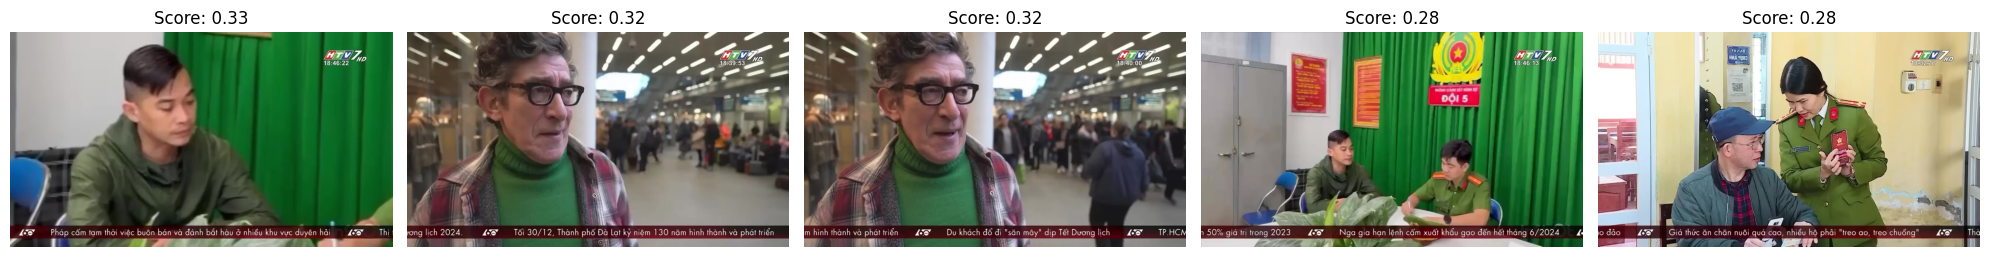

In [48]:
search_similar_images(
    query=query,
    clip_embeddings=clip_embeds,
    caption_embeddings=caption_embeds,
    image_files=image_files,
    image_folder=image_folder,
    modality="clip",
    tokenizer=clip_tokenizer,
    clip_model=clip_model,
    embedder=embedder
)


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


🔍 Query: "a man wearing a green jacket is speaking"  | Modality: CAPTION
📸 Top 5 matching images:

🔹 Rank 1: 214.jpg (Score: 0.6911)
🔹 Rank 2: 177.jpg (Score: 0.3967)
🔹 Rank 3: 117.jpg (Score: 0.3799)
🔹 Rank 4: 133.jpg (Score: 0.3568)
🔹 Rank 5: 033.jpg (Score: 0.3367)


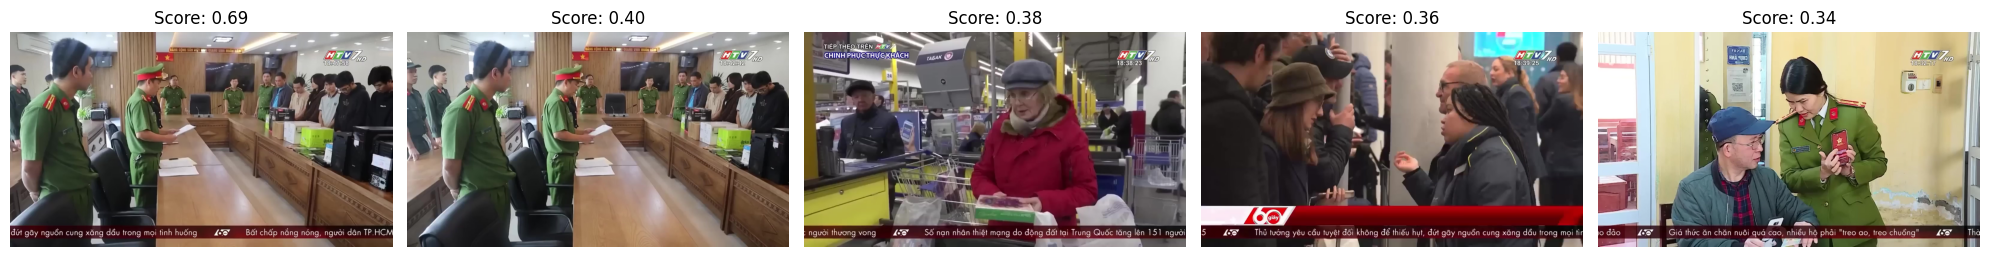

In [49]:
search_similar_images(
    query=query,
    clip_embeddings=clip_embeds,
    caption_embeddings=caption_embeds,
    image_files=image_files,
    image_folder=image_folder,
    modality="caption",
    tokenizer=clip_tokenizer,
    clip_model=clip_model,
    embedder=embedder
)


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


🔍 Query: "a man wearing a green jacket is speaking"  | Modality: FUSION
📸 Top 5 matching images:

🔹 Rank 1: 214.jpg (Score: 0.4396)
🔹 Rank 2: 177.jpg (Score: 0.3210)
🔹 Rank 3: 033.jpg (Score: 0.3013)
🔹 Rank 4: 217.jpg (Score: 0.2870)
🔹 Rank 5: 133.jpg (Score: 0.2840)


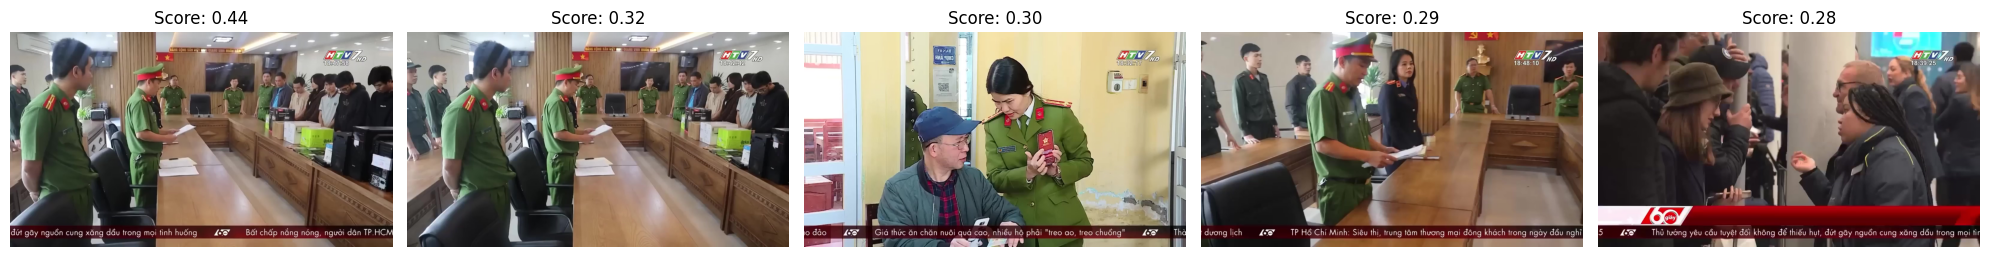

In [47]:
search_similar_images(
    query=query,
    clip_embeddings=clip_embeds,
    caption_embeddings=caption_embeds,
    image_files=image_files,
    image_folder=image_folder,
    modality="fusion",
    tokenizer=clip_tokenizer,
    clip_model=clip_model,
    embedder=embedder
)


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


🔍 Query: "a man wearing a green jacket is speaking"  | Modality: RRF
📸 Top 5 matching images:

🔹 Rank 1: 214.jpg (Score: 0.0318)
🔹 Rank 2: 177.jpg (Score: 0.0313)
🔹 Rank 3: 033.jpg (Score: 0.0312)
🔹 Rank 4: 217.jpg (Score: 0.0291)
🔹 Rank 5: 133.jpg (Score: 0.0279)


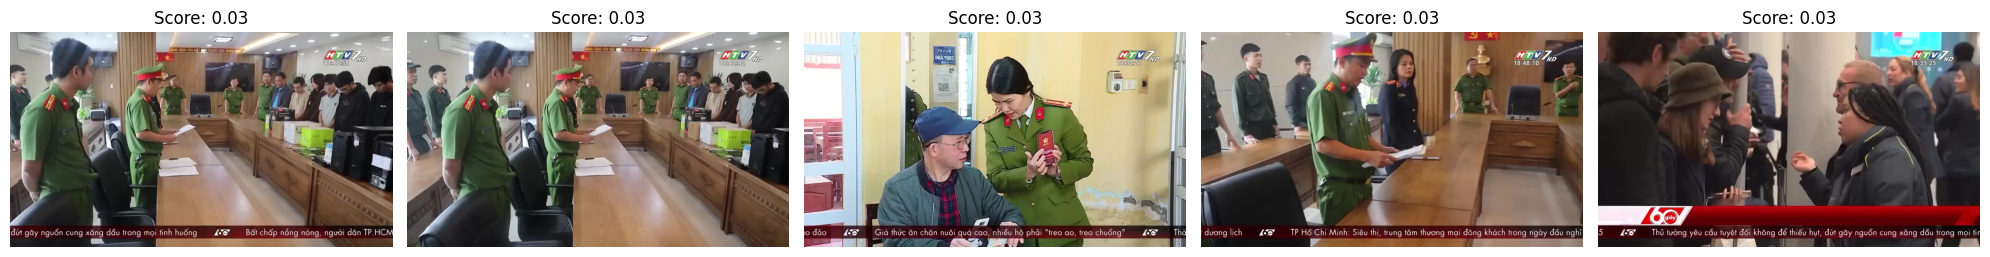

In [50]:
search_similar_images(
    query=query,
    clip_embeddings=clip_embeds,
    caption_embeddings=caption_embeds,
    image_files=image_files,
    image_folder=image_folder,
    modality="rrf",
    tokenizer=clip_tokenizer,
    clip_model=clip_model,
    embedder=embedder
)
